# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 1. 데이터 로딩 및 기초 탐색

**목표**
- train_transaction + train_identity 메모리 효율적 로딩
- TransactionID 기준 결합
- 결측률, 기초 통계, 클래스 비율 1차 확인

**환경 제약**
- RAM 16GB 미만 → dtype 다운캐스팅 필수 (raw 그대로 읽으면 메모리 부족 위험)
- train_transaction.csv 단독으로도 약 590,540행 × 394열

+ Pandas에서 데이터형 다운캐스팅(Downcasting): 메모리 사용량을 줄이기 위해 숫자 데이터 타입을 더 적은 메모리를 차지하는 작은 타입(예: float64 → float32, int64 → int8)으로 변환하는 기법

### 1. 라이브러리 임포트 및 경로 설정

In [ ]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', 100) 
# 최대 100개 칼럼까지 잘리지 않고 다 보여주는 
# None: 전부 다 보여줌
# 한 번 설정해두면 세션동안 계속 적용됨

DATA_DIR = "../data/raw"  # 데이터셋 경로
TRANSACTION_PATH = os.path.join(DATA_DIR, "train_transaction.csv")
IDENTITY_PATH = os.path.join(DATA_DIR, "train_identity.csv")

print(os.path.exists(TRANSACTION_PATH), os.path.exists(IDENTITY_PATH))

True True


### 2. 메모리 최적화 로딩 함수

16GB 미만 RAM 환경이므로, pandas 기본 `read_csv`로 바로 읽으면 float64/int64 기본 dtype 때문에 메모리가 과도하게 부풀어요.
컬럼별 최소/최대값을 확인해 다운캐스팅하는 `reduce_mem_usage` 함수를 먼저 정의합니다.

이전 IBM 프로젝트에서 청크 스트리밍으로 대용량 CSV를 처리했던 것과 유사한 맥락인데, 여기서는 한 파일 크기가 더 작아(transaction 기준 약 680MB) 청크 스트리밍 없이 dtype 최적화만으로 충분할 가능성이 높습니다. 다만 로딩 직후 메모리 사용량을 꼭 확인하고, 부족하면 청크 방식으로 전환합니다.

In [7]:
def reduce_mem_usage(df, verbose=True):
    """컬럼별 값 범위를 확인해 더 작은 dtype으로 다운캐스팅"""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:  # float
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"메모리 사용량: {start_mem:.2f} MB → {end_mem:.2f} MB ({100*(start_mem-end_mem)/start_mem:.1f}% 감소)")
    
    return df

### 3. 데이터 로딩

`isFraud`(타겟), `TransactionDT`(시간), `TransactionID`(조인 키)는 다운캐스팅 전에 따로 보존해 의미가 바뀌지 않도록 합니다.
범주형으로 변환된 컬럼은 이후 통계검정(4.1절)에서 다시 활용합니다.

In [15]:
# transaction 로딩
df_train_transaction = pd.read_csv(TRANSACTION_PATH)
print("transaction raw shape:", df_train_transaction.shape)
df_train_transaction = reduce_mem_usage(df_train_transaction)

# identity 로딩
df_train_identity = pd.read_csv(IDENTITY_PATH)
print("identity raw shape:", df_train_identity.shape)
df_train_identity = reduce_mem_usage(df_train_identity)

transaction raw shape: (590540, 394)
메모리 사용량: 2062.07 MB → 861.12 MB (58.2% 감소)
identity raw shape: (144233, 41)
메모리 사용량: 143.14 MB → 16.17 MB (88.7% 감소)


### 4. TransactionID 기준 결합

Kaggle 설명대로 모든 거래에 identity 정보가 있는 것은 아닙니다(약 21%만 보유). `left join`으로 transaction을 기준으로 결합하여 정보 손실 없이 매칭 여부를 그대로 보존합니다.

In [16]:
df = df_train_transaction.merge(df_train_identity, on='TransactionID', how='left')

print("결합 후 shape:", df.shape)

# identity 매칭 여부 자체를 변수로 보존 (2.2절: Transaction-Identity 비대칭 → 이후 변수 후보)
df['has_identity'] = df['TransactionID'].isin(df_train_identity['TransactionID']).astype(np.int8)

print("\nisFraud 비율:\n", df['isFraud'].value_counts(normalize=True))
print("\nidentity 매칭 비율:\n", df['has_identity'].value_counts(normalize=True))

# identity 보유 여부에 따른 사기 비율 교차 확인
print("\nidentity 보유 여부별 사기 비율:")
print(df.groupby('has_identity')['isFraud'].mean())

print("\nidentity 보유 여부 × isFraud 교차표 (건수):")
print(pd.crosstab(df['has_identity'], df['isFraud']))

print("\nidentity 보유 여부 × isFraud 교차표 (행 기준 비율):")
print(pd.crosstab(df['has_identity'], df['isFraud'], normalize='index'))

결합 후 shape: (590540, 434)

isFraud 비율:
 isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

identity 매칭 비율:
 has_identity
0    0.755761
1    0.244239
Name: proportion, dtype: float64

identity 보유 여부별 사기 비율:
has_identity
0    0.020939
1    0.078470
Name: isFraud, dtype: float64

identity 보유 여부 × isFraud 교차표 (건수):
isFraud            0      1
has_identity               
0             436962   9345
1             132915  11318

identity 보유 여부 × isFraud 교차표 (행 기준 비율):
isFraud              0         1
has_identity                    
0             0.979061  0.020939
1             0.921530  0.078470


**칼럼 434인 이유**
- 394 + 41 - 1(중복 조인키 TransactionID) = 434
- has_identity까지 435

**isin vs apply 차이**

- 핵심 차이: isin은 "찾는 작업"에 최적화된 전용 함수, apply는 "행/값마다 직접 만든 함수를 돌리는" 범용 도구
+ isin: "이 컬럼 값들이 저 리스트(또는 다른 컬럼)에 있는지 없는지" 같은 단순 포함 여부 확인에 쓰는 전용 함수. 빠름.
+ apply: 행마다 적용할 로직이 isin, map, 산술연산 같은 pandas 내장 기능으로 표현이 안 될 때 쓰는 범용 함수. pandas가 한 행씩 Python으로 직접 호출해야 해서 느림.

### 5. 메모리 사용량 점검

다운캐스팅 + 결합 후 실제 메모리 사용량을 확인합니다. 만약 16GB RAM 환경에서 위험한 수준(예: 8GB 이상)이면, 이후 단계부터는 필요한 컬럼만 골라 작업하거나 `del`로 원본 DataFrame을 즉시 해제하는 방식을 추가로 적용합니다.

In [12]:
import gc

mem_gb = df.memory_usage(deep=True).sum() / 1024**3
print(f"결합 데이터 메모리 사용량: {mem_gb:.2f} GB")

# 원본 개별 DataFrame은 더 이상 필요 없으므로 해제
del df_train_transaction, df_train_identity
gc.collect()

결합 데이터 메모리 사용량: 0.90 GB


519

### 5-1. 다운캐스팅 무결성 검증

메모리 최적화(dtype 다운캐스팅)가 데이터 신뢰성에 영향을 주지 않았는지 검증합니다.

- **정수형(int) 컬럼**: 값 범위 내에서의 다운캐스팅이므로 100% 무손실
- **실수형(float) 컬럼**: float64 → float32 변환 시 발생 가능한 정밀도 손실 정도를 확인
- **결측치**: 다운캐스팅 전후 결측치 개수가 동일한지 확인 (category 변환 시 결측치가 의도와 다르게 처리될 가능성 점검)

In [17]:
# 1) float 다운캐스팅 오차 검증 (TransactionAmt 샘플 기준)
sample_check = pd.read_csv(TRANSACTION_PATH, usecols=['TransactionAmt'], nrows=10000)
sample_check_f32 = sample_check['TransactionAmt'].astype(np.float32)

diff = (sample_check['TransactionAmt'] - sample_check_f32.astype(np.float64)).abs()
max_diff = diff.max()
affected_ratio = (diff > 0).sum() / len(diff)

print(f"[float 다운캐스팅 검증] 최대 오차: {max_diff:.2e}")
print(f"[float 다운캐스팅 검증] 오차 발생 비율: {affected_ratio:.1%} ({(diff > 0).sum()} / {len(diff)})")
print(f"[float 다운캐스팅 검증] 판단: 오차 크기가 거래금액 단위(센트, 0.01)의 "
      f"{max_diff / 0.01:.6f}배 수준 → 분석/모델링에 실질적 영향 없음\n")

# 2) 결측치 무결성 검증 (다운캐스팅 후 결측치 총합)
missing_after_transaction = df['isFraud'].isnull().sum()  # 타겟 컬럼 결측 없어야 정상
print(f"[결측치 검증] isFraud 결측 개수: {missing_after_transaction} (정상이면 0)")

missing_total = df.isnull().sum().sum()
print(f"[결측치 검증] 전체 결측치 총합 (다운캐스팅+병합 후): {missing_total:,}")

[float 다운캐스팅 검증] 최대 오차: 8.79e-05
[float 다운캐스팅 검증] 오차 발생 비율: 34.4% (3443 / 10000)
[float 다운캐스팅 검증] 판단: 오차 크기가 거래금액 단위(센트, 0.01)의 0.008789배 수준 → 분석/모델링에 실질적 영향 없음

[결측치 검증] isFraud 결측 개수: 0 (정상이면 0)
[결측치 검증] 전체 결측치 총합 (다운캐스팅+병합 후): 115,523,073


**검증 결과 요약**

| 항목 | 결과 | 판단 |
|---|---|---|
| float32 다운캐스팅 최대 오차 | 8.79 × 10⁻⁵ | 거래금액 최소 단위(0.01)의 0.0088배 → 무시 가능 |
| 오차 발생 비율 | 34.43% (3,443 / 10,000) | 발생은 하지만 크기가 분석에 영향 없는 수준 |
| isFraud 결측치 | 0건 (정상) | 타겟 라벨 무결성 보존 확인 |

**결론**: 다운캐스팅은 데이터의 통계적 신뢰성과 무결성을 훼손하지 않았으며, 이후 모든 통계검정·모델링 단계에서 다운캐스팅된 데이터를 그대로 사용한다.

### 6. 컬럼별 결측률 분석

전체 결측치 총합(45%)은 어떤 컬럼이 결측을 주도하는지 보여주지 못합니다. 컬럼별로 결측률을 계산해 분포를 확인하고, 이후 4.3절(결측 플래그 변수 설계)의 대상 컬럼을 좁히는 기초 자료로 사용합니다.

In [20]:
missing_ratio = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print("결측률 상위 20개 컬럼:")
print(missing_ratio.head(20))

print("\n결측률 구간별 컬럼 개수:")
bins = [0, 1, 10, 50, 90, 100.0001]
labels = ['0~1%', '1~10%', '10~50%', '50~90%', '90% 이상']
missing_dist = pd.cut(missing_ratio, bins=bins, labels=labels, right=False).value_counts().sort_index()
print(missing_dist)

print(f"\n결측치가 전혀 없는 컬럼 개수: {(missing_ratio == 0).sum()}")

결측률 상위 20개 컬럼:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_22    99.124699
id_27    99.124699
id_23    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
D8       87.312290
dtype: float64

결측률 구간별 컬럼 개수:
0~1%      112
1~10%       1
10~50%    108
50~90%    202
90% 이상     12
Name: count, dtype: int64

결측치가 전혀 없는 컬럼 개수: 21


### 7. 컬럼 그룹(prefix)별 결측률 패턴

IEEE-CIS 변수명은 prefix로 그룹화되어 있습니다(V*, C*, D*, M*, id_* 등). 개별 컬럼 단위가 아니라 그룹 단위로 결측률 분포를 보면, 어떤 변수군이 구조적으로 결측이 많은지 파악할 수 있고 4.3절 파생변수 설계 우선순위를 정하는 데 활용합니다.

(prefix= 접두사)

In [21]:
import re

def get_prefix(col):
    # 컬럼명에서 숫자를 제거한 prefix 추출 (예: V128 -> V, id_24 -> id_, card3 -> card)
    match = re.match(r'^([A-Za-z_]+)', col)
    return match.group(1) if match else col

prefix_missing = (
    missing_ratio.rename('missing_pct')
    .reset_index()
    .rename(columns={'index': 'column'})
)
prefix_missing['prefix'] = prefix_missing['column'].apply(get_prefix)

prefix_summary = prefix_missing.groupby('prefix').agg(
    col_count=('column', 'count'),
    mean_missing_pct=('missing_pct', 'mean'),
    min_missing_pct=('missing_pct', 'min'),
    max_missing_pct=('missing_pct', 'max'),
).sort_values('mean_missing_pct', ascending=False)

print(prefix_summary)

                col_count  mean_missing_pct  min_missing_pct  max_missing_pct
prefix                                                                       
id_                    38         84.823271        75.576083        99.196159
DeviceInfo              1         79.905510        79.905510        79.905510
R_emaildomain           1         76.751617        76.751617        76.751617
dist                    2         76.640363        59.652352        93.628374
DeviceType              1         76.155722        76.155722        76.155722
D                      15         58.151263         0.214888        93.409930
M                       9         49.923328        28.678836        59.349409
V                     339         43.038469         0.002032        86.123717
P_emaildomain           1         15.994852        15.994852        15.994852
addr                    2         11.126427        11.126427        11.126427
card                    6          0.505328         0.000000    

### 8. V 컬럼군 결측률 기반 하위 클러스터 확인

V 컬럼은 339개로 단일 그룹으로 보기엔 결측률 편차가 너무 큽니다(0.002%~86%). 결측률이 동일/유사한 V컬럼들은 같은 데이터 출처에서 파생되었을 가능성이 높다는 점에 착안하여, 결측률 값 기준으로 V컬럼을 하위 클러스터링합니다. 이는 4.3절에서 V컬럼 차원축소(또는 대표 변수 선정)의 기초 자료로 활용합니다.

In [22]:
v_cols = [c for c in df.columns if c.startswith('V')]
v_missing = (df[v_cols].isnull().sum() / len(df) * 100).round(4)

# 결측률이 동일한 V컬럼들을 그룹으로 묶기
v_missing_groups = v_missing.reset_index().rename(columns={'index': 'column', 0: 'missing_pct'})
v_missing_groups.columns = ['column', 'missing_pct']

group_summary = v_missing_groups.groupby('missing_pct')['column'].apply(list).reset_index()
group_summary['n_cols'] = group_summary['column'].apply(len)
group_summary = group_summary.sort_values('n_cols', ascending=False)

print(f"V컬럼 {len(v_cols)}개가 결측률 기준으로 {len(group_summary)}개의 고유 그룹으로 묶임\n")
print("컬럼 수 기준 상위 10개 그룹:")
for _, row in group_summary.head(10).iterrows():
    print(f"  결측률 {row['missing_pct']:.4f}% | {row['n_cols']}개 컬럼 | 예: {row['column'][:5]}{'...' if row['n_cols'] > 5 else ''}")

V컬럼 339개가 결측률 기준으로 15개의 고유 그룹으로 묶임

컬럼 수 기준 상위 10개 그룹:
  결측률 77.9134% | 46개 컬럼 | 예: ['V217', 'V218', 'V219', 'V223', 'V224']...
  결측률 0.0532% | 43개 컬럼 | 예: ['V95', 'V96', 'V97', 'V98', 'V99']...
  결측률 0.0020% | 32개 컬럼 | 예: ['V279', 'V280', 'V284', 'V285', 'V286']...
  결측률 76.3554% | 31개 컬럼 | 예: ['V167', 'V168', 'V172', 'V173', 'V176']...
  결측률 12.8819% | 23개 컬럼 | 예: ['V12', 'V13', 'V14', 'V15', 'V16']...
  결측률 13.0552% | 22개 컬럼 | 예: ['V53', 'V54', 'V55', 'V56', 'V57']...
  결측률 15.0987% | 20개 컬럼 | 예: ['V75', 'V76', 'V77', 'V78', 'V79']...
  결측률 76.3235% | 19개 컬럼 | 예: ['V169', 'V170', 'V171', 'V174', 'V175']...
  결측률 28.6126% | 18개 컬럼 | 예: ['V35', 'V36', 'V37', 'V38', 'V39']...
  결측률 86.1237% | 18개 컬럼 | 예: ['V138', 'V139', 'V140', 'V141', 'V142']...


**V컬럼 하위 클러스터링 방식**
- 각 V컬럼의 결측률을 계산한 뒤, 결측률 숫자가 똑같은 컬럼들을 groupby로 한 묶음씩 모은 것. 
- 클러스터링이라고 부르긴 했지만, 실제로는 머신러닝 클러스터링 알고리즘(K-means 같은)을 쓴 게 아니라 **"같은 값끼리 그룹화"**하는 단순한 groupby 집계임. 
- 339개 컬럼이 결측률 기준 15개의 고유값으로만 떨어진다는 게 신기한 부분이고, 그래서 이 단순한 방법으로도 의미 있는 그룹이 잡힌 것

### 9. 결측 행 일치 여부 검증

결측률이 동일한 V컬럼들이 실제로 "같은 행에서" 결측인지 확인합니다. 만약 결측 패턴(어느 행이 비어있는지)까지 동일하다면, 이 컬럼들은 같은 데이터 출처/집계 로직에서 나왔다는 근거가 강해지고, 그룹 내 대표 변수 선정 또는 PCA 적용의 타당성이 높아집니다.

In [23]:
# 최대 그룹(46개 컬럼, 결측률 77.91%)으로 검증
largest_group_cols = group_summary.iloc[0]['column']
print(f"검증 대상: {len(largest_group_cols)}개 컬럼, 결측률 {group_summary.iloc[0]['missing_pct']:.4f}%\n")

# 각 행에서 이 컬럼들의 결측 패턴(True/False 조합)이 모두 같은지 확인
missing_pattern = df[largest_group_cols].isnull()
unique_patterns = missing_pattern.drop_duplicates()

print(f"이론적 최대 패턴 수: 2^{len(largest_group_cols)} (사실상 무한)")
print(f"실제 발견된 고유 결측 패턴 수: {len(unique_patterns)}")
print(f"\n→ 고유 패턴이 2개(전부 결측 / 전부 비결측)에 가까우면, '같은 행에서 함께 결측'한다는 뜻")

# 행 단위로 "이 그룹 컬럼들이 전부 NaN이거나 전부 NaN이 아닌" 비율 확인
all_missing_or_all_present = missing_pattern.apply(lambda row: row.all() or (~row).all(), axis=1)
print(f"\n전부결측 또는 전부비결측인 행의 비율: {all_missing_or_all_present.mean():.4%}")

검증 대상: 46개 컬럼, 결측률 77.9134%

이론적 최대 패턴 수: 2^46 (사실상 무한)
실제 발견된 고유 결측 패턴 수: 2

→ 고유 패턴이 2개(전부 결측 / 전부 비결측)에 가까우면, '같은 행에서 함께 결측'한다는 뜻

전부결측 또는 전부비결측인 행의 비율: 100.0000%


### 10. V컬럼 전체 그룹에 대한 결측 패턴 일치 검증 및 축소 전략 확정

가장 큰 그룹(46개 컬럼)에서 결측 패턴이 100% 일치함을 확인했습니다. 이를 15개 그룹 전체로 일반화하여 검증하고, 각 그룹의 대표 변수 선정(또는 PCA 1순위 주성분) 및 그룹당 결측 플래그 1개 생성 전략을 4.3절 Feature Engineering의 구체적 실행 계획으로 확정합니다.

In [ ]:
group_validation = []

for _, row in group_summary.iterrows():
    cols = row['column']
    pattern = df[cols].isnull()
    # 그룹 내 모든 컬럼이 행 단위로 전부 결측이거나 전부 비결측인 비율
    # 15번 반복되는 루프 안이라 속도가 중요해져서, 이전 셀의 apply 대신 벡터화 연산으로 바꿈
    consistency = (pattern.all(axis=1) | (~pattern).all(axis=1)).mean()
    group_validation.append({
        'missing_pct': row['missing_pct'],
        'n_cols': row['n_cols'],
        'pattern_consistency': consistency
    })

group_validation_df = pd.DataFrame(group_validation).sort_values('n_cols', ascending=False)
print(group_validation_df.to_string(index=False))

print(f"\n전체 V컬럼 {len(v_cols)}개 중, 패턴 일치도 99% 이상인 그룹에 속한 컬럼 수:")
consistent_groups = group_validation_df[group_validation_df['pattern_consistency'] >= 0.99]
print(consistent_groups['n_cols'].sum(), "개")

 missing_pct  n_cols  pattern_consistency
     77.9134      46                  1.0
      0.0532      43                  1.0
      0.0020      32                  1.0
     76.3554      31                  1.0
     12.8819      23                  1.0
     13.0552      22                  1.0
     15.0987      20                  1.0
     76.3235      19                  1.0
     28.6126      18                  1.0
     86.1237      18                  1.0
     86.0550      18                  1.0
     76.0531      16                  1.0
      0.2149      11                  1.0
     47.2935      11                  1.0
     86.1227      11                  1.0

전체 V컬럼 339개 중, 패턴 일치도 99% 이상인 그룹에 속한 컬럼 수:
339 개


## Day 1 요약

**완료한 작업**
1. 메모리 최적화 로딩 (transaction 58.2%, identity 88.7% 감소) + 다운캐스팅 무결성 검증
2. transaction-identity 병합 (590,540행 × 434열) + has_identity 변수 생성
3. 컬럼별/그룹(prefix)별 결측률 분석
4. V컬럼(339개) 결측 패턴 기반 그룹 검증 → 15개 그룹, 100% 패턴 일치 확인

**핵심 발견**
- 클래스 불균형: 사기 비율 3.499%
- identity 보유 거래의 사기 비율(7.85%)이 미보유 거래(2.09%)보다 3.7배 높음 → 통계적 검증 대상(Day 2)
- id_*, Device*, R_emaildomain, dist* 컬럼의 결측은 has_identity와 강하게 연관
- V컬럼 339개 → 15개 결측 패턴 그룹으로 100% 정확히 분해 → 그룹별 차원축소 대상(Day 3)

**Day 2로 넘어가기 전 확정할 파생/검정 대상**
- 카이제곱 검정 대상: ProductCD, card4, card6, DeviceType, has_identity
- t-test/Mann-Whitney 대상: TransactionAmt
- 결측 패턴 검정 대상: V컬럼 그룹 15개의 결측 플래그, id_* 그룹 결측 플래그

## Day 1 (후반). 핵심 변수 분포 및 이상치 탐색

결측 구조 파악에 이어, 모델링과 파생변수 설계의 기초가 되는 핵심 변수들의 분포를 확인합니다.

### 11. TransactionAmt (거래금액) 분포

In [25]:
print("TransactionAmt 기초 통계:")
print(df['TransactionAmt'].describe())

print("\n사기 여부별 거래금액 기초 통계:")
print(df.groupby('isFraud')['TransactionAmt'].describe())

# 상위 1% 극단값 확인 (이상치 후보)
print("\n상위 1% 분위수:", df['TransactionAmt'].quantile(0.99))
print("최댓값:", df['TransactionAmt'].max())

TransactionAmt 기초 통계:
count    590540.000000
mean        135.027176
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

사기 여부별 거래금액 기초 통계:
            count        mean         std    min        25%   50%    75%  \
isFraud                                                                    
0        569877.0  134.511658  239.395081  0.251  43.970001  68.5  120.0   
1         20663.0  149.244766  232.212158  0.292  35.043999  75.0  161.0   

                  max  
isFraud                
0        31937.390625  
1         5191.000000  

상위 1% 분위수: 1104.0
최댓값: 31937.39


거래금액은 일반적으로 우측으로 긴 꼬리(right-skewed) 분포를 가지므로, 로그 변환 전후 분포를 함께 시각화하여 확인합니다. 사기/정상 그룹의 분포 차이도 함께 봅니다.

In [27]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

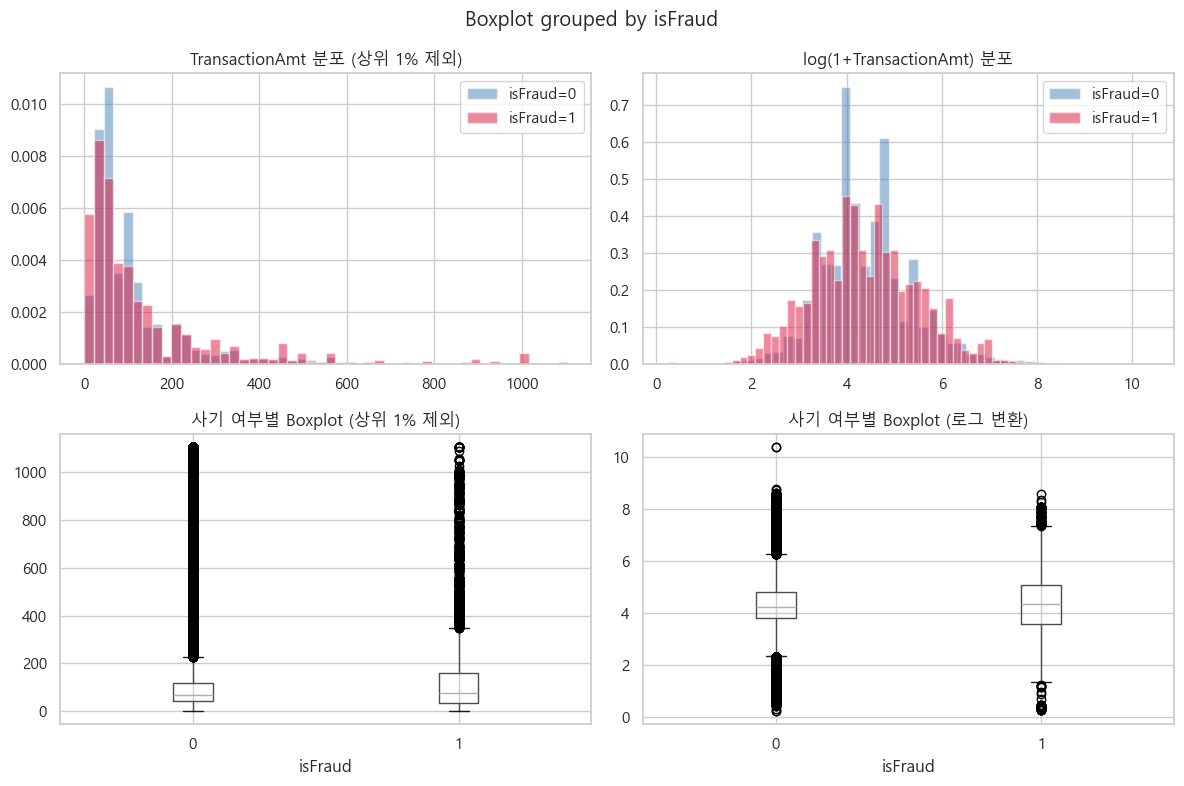

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 원본 분포 (사기/정상 비교, 상위 1% 제외하고 시각화 - 극단값 때문에 분포가 안 보일 수 있음)
amt_clip = df['TransactionAmt'].quantile(0.99)
for fraud_val, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = df[(df['isFraud'] == fraud_val) & (df['TransactionAmt'] <= amt_clip)]
    axes[0, 0].hist(subset['TransactionAmt'], bins=50, alpha=0.5, label=f'isFraud={fraud_val}', color=color, density=True)
axes[0, 0].set_title('TransactionAmt 분포 (상위 1% 제외)')
axes[0, 0].legend()

# 로그 변환 분포
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
for fraud_val, color in [(0, 'steelblue'), (1, 'crimson')]:
    subset = df[df['isFraud'] == fraud_val]
    axes[0, 1].hist(subset['TransactionAmt_log'], bins=50, alpha=0.5, label=f'isFraud={fraud_val}', color=color, density=True)
axes[0, 1].set_title('log(1+TransactionAmt) 분포')
axes[0, 1].legend()

# Boxplot (상위 1% 제외)
df[df['TransactionAmt'] <= amt_clip].boxplot(column='TransactionAmt', by='isFraud', ax=axes[1, 0])
axes[1, 0].set_title('사기 여부별 Boxplot (상위 1% 제외)')

# 로그 변환 Boxplot
df.boxplot(column='TransactionAmt_log', by='isFraud', ax=axes[1, 1])
axes[1, 1].set_title('사기 여부별 Boxplot (로그 변환)')

plt.tight_layout()
plt.savefig('../reports/figures/day1_transactionamt_distribution.png', dpi=100)
plt.show()

### TransactionAmt 분석 결과 요약

- 평균은 사기(149.24)가 정상(134.51)보다 약간 높으나, 표준편차가 매우 커서(232~239) 평균 차이만으로는 유의미하다고 보기 어려움
- 분위수별로 역전 패턴이 나타남: 25%는 사기가 더 낮고(35.04 vs 43.97), 50%·75%는 사기가 더 높음(75 vs 68.5, 161 vs 120) → 사기 거래가 양극단(소액+고액)으로 더 퍼져있는 분포로 추정됨
- 최댓값은 정상(31,937)이 사기(5,191)보다 훨씬 큼 → 초고액 거래는 오히려 정상 거래에서 발생하는 것으로 확인됨
- 원본 분포(상위 1% 제외)에서 사기가 저액 구간(0~150)에 더 몰려있는 패턴이 시각적으로 확인됨
- 로그 변환 후에도 사기 분포가 정상보다 더 평평하고 넓게 퍼진 형태로 나타남
- Boxplot 기준 사기 그룹의 IQR이 정상보다 넓게 나타나, 사기 거래의 금액 변동성이 더 큰 것으로 판단됨
- 분포가 정규분포를 따르지 않고(우측 꼬리 매우 길음) 두 그룹 간 분산도 다른 것으로 보여, Day 2 통계검정은 t-test보다 **Mann-Whitney U test**가 더 적합할 것으로 판단됨 (정규성/등분산 정식 검정은 Day 2에서 진행)
- 극단값은 제거 대상이 아니라 사기탐지의 핵심 신호일 가능성이 높으므로, 이상치 제거 대신 로그 변환과 사용자별 금액 편차(z-score, 2.4절 파생변수)로 다루는 방향이 적절함

### 12. card1~card6, ProductCD 분포

card1~card6는 4.3절 UID 설계(card1+card2+addr1+D1 조합)에 직접 사용되는 변수이므로, 유니크 값 개수와 분포를 먼저 확인합니다.

In [30]:
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']

for col in card_cols:
    print(f"--- {col} ---")
    print(f"고유값 개수: {df[col].nunique()}")
    print(f"결측 개수: {df[col].isnull().sum()} ({df[col].isnull().mean():.2%})")
    if df[col].nunique() <= 10:
        print(df[col].value_counts(dropna=False))
    else:
        print(df[col].value_counts(dropna=False).head(5), "... (상위 5개만 표시)")
    print()

print("--- ProductCD ---")
print(df['ProductCD'].value_counts(dropna=False))
print("\nProductCD별 사기 비율:")
print(df.groupby('ProductCD', observed=True)['isFraud'].mean().sort_values(ascending=False))

--- card1 ---
고유값 개수: 13553
결측 개수: 0 (0.00%)
card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
Name: count, dtype: int64 ... (상위 5개만 표시)

--- card2 ---
고유값 개수: 500
결측 개수: 8933 (1.51%)
card2
321.0    48935
111.0    45191
555.0    41995
490.0    38145
583.0    21803
Name: count, dtype: int64 ... (상위 5개만 표시)

--- card3 ---
고유값 개수: 114
결측 개수: 1565 (0.27%)
card3
150.0    521287
185.0     56346
106.0      1571
NaN        1565
146.0      1252
Name: count, dtype: int64 ... (상위 5개만 표시)

--- card4 ---
고유값 개수: 4
결측 개수: 1577 (0.27%)
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

--- card5 ---
고유값 개수: 119
결측 개수: 4259 (0.72%)
card5
226.0    296546
224.0     81513
166.0     57140
102.0     29105
117.0     25941
Name: count, dtype: int64 ... (상위 5개만 표시)

--- card6 ---
고유값 개수: 4
결측 개수: 1571 (0.27%)
card6
debit              439938
credit             1489

### card1~card6, ProductCD 분석 결과 요약

- card1은 고유값 13,553개로 매우 세분화되어 카드를 거의 식별 가능한 수준 → UID 조합 변수의 핵심 후보로 적합함
- card2, card3, card5는 결측률이 0.27~1.51%로 미미하여 안전하게 사용 가능한 것으로 확인됨
- card4(카드 브랜드)는 visa(65%)·mastercard(32%)가 대부분을 차지하며 범주가 4개로 적어 카이제곱 검정에 적합함
- card6(카드 타입)은 debit(74.5%)·credit(25.2%)이 대부분이며, "debit or credit"(30건)·"charge card"(15건)는 표본이 지나치게 작아 통계검정 시 별도 처리(병합 또는 제외)가 필요한 것으로 판단됨
- **ProductCD별 사기 비율 차이가 매우 크게 나타남(C 11.69% ~ W 2.04%, 약 6배 차이)** → 카이제곱 검정에서 유의할 가능성이 높은 핵심 변수로 확인됨
- 주력 제품(W, 전체의 74%)의 사기 비율이 가장 낮고, 소수 제품(C, 전체의 12%)의 사기 비율이 가장 높음 → 제품군에 따른 사기 위험도 차이가 뚜렷한 것으로 판단됨

### 13. TransactionDT(시간 변수) 범위 확인

TransactionDT는 실제 타임스탬프가 아닌 임의 기준점으로부터의 경과초(timedelta)이므로, 전체 데이터가 며칠/몇 개월치 범위인지 먼저 확인합니다. 이는 4.3절 시간 파생변수(month 등) 및 4.11절 Drift 분석의 시간 구간 분할 기준이 됩니다.

In [31]:
print("TransactionDT 범위:")
print(f"최솟값: {df['TransactionDT'].min()}, 최댓값: {df['TransactionDT'].max()}")

total_seconds = df['TransactionDT'].max() - df['TransactionDT'].min()
print(f"\n전체 기간: {total_seconds / 86400:.1f}일 (약 {total_seconds / 86400 / 30:.1f}개월)")

# 일 단위로 변환하여 거래 분포 확인
df['Transaction_day'] = (df['TransactionDT'] / 86400).astype(int)
print(f"\n일자(0~{df['Transaction_day'].max()}) 기준 거래 건수 분포:")
print(df['Transaction_day'].describe())

TransactionDT 범위:
최솟값: 86400, 최댓값: 15811131

전체 기간: 182.0일 (약 6.1개월)

일자(0~182) 기준 거래 건수 분포:
count    590540.000000
mean         84.729199
std          53.437277
min           1.000000
25%          35.000000
50%          84.000000
75%         130.000000
max         182.000000
Name: Transaction_day, dtype: float64


### TransactionDT(시간 변수) 분석 결과 요약

- 전체 데이터는 약 182일(6.1개월) 분량으로 확인됨
- 거래 일자(0~182일)는 25%(35일)~75%(130일) 구간에 고르게 분포하며, 중앙값(84일)이 전체 기간의 중간 지점과 거의 일치하여 특정 시기에 거래가 몰리지 않고 비교적 균등하게 분포된 것으로 판단됨
- 6개월 분량의 데이터이므로, 4.3절 시간 파생변수(month)는 약 6개 구간으로 나뉠 것으로 예상되며, 4.11절 Drift 분석의 학습/검증 구간 분할(예: 초반 4개월 학습 vs 최근 2개월 검증) 설계가 가능한 것으로 확인됨

### 14. C1~C14 분포 확인

C1~C14는 결측이 0%인 수치형 변수군으로, 거래 관련 카운트(예: 동일 카드/주소와 연관된 건수)로 추정됩니다. 분포와 사기 여부와의 관계를 확인합니다.

In [32]:
c_cols = [f'C{i}' for i in range(1, 15)]

print("C1~C14 기초 통계:")
print(df[c_cols].describe().T)

print("\n사기 여부별 평균값 비교:")
print(df.groupby('isFraud', observed=True)[c_cols].mean().T)

C1~C14 기초 통계:
        count       mean         std  min  25%  50%   75%     max
C1   590540.0  14.092458  133.569016  0.0  1.0  1.0   3.0  4685.0
C2   590540.0  15.269734  154.668900  0.0  1.0  1.0   3.0  5691.0
C3   590540.0   0.005644    0.150536  0.0  0.0  0.0   0.0    26.0
C4   590540.0   4.092185   68.848457  0.0  0.0  0.0   0.0  2253.0
C5   590540.0   5.571526   25.786976  0.0  0.0  0.0   1.0   349.0
C6   590540.0   9.071082   71.508469  0.0  1.0  1.0   2.0  2253.0
C7   590540.0   2.848478   61.727303  0.0  0.0  0.0   0.0  2255.0
C8   590540.0   5.144575   95.378571  0.0  0.0  0.0   0.0  3331.0
C9   590540.0   4.480240   16.674896  0.0  0.0  1.0   2.0   210.0
C10  590540.0   5.240343   95.581444  0.0  0.0  0.0   0.0  3257.0
C11  590540.0  10.241521   94.336288  0.0  1.0  1.0   2.0  3188.0
C12  590540.0   4.076227   86.666214  0.0  0.0  0.0   0.0  3188.0
C13  590540.0  32.539921  129.364853  0.0  1.0  3.0  12.0  2918.0
C14  590540.0   8.295215   49.544262  0.0  1.0  1.0   2.0  142

### C1~C14 분석 결과 요약

- 모든 C컬럼이 75분위는 작은 값(0~12)이나 최댓값은 수천 단위까지 나타나는 극단적 우측 꼬리 분포를 보임 → TransactionAmt와 유사하게 로그 변환이 적합할 것으로 판단됨
- 사기 여부에 따라 두 가지 상반된 패턴이 확인됨
  - C1, C2, C4, C6, C7, C8, C10, C11, C12, C14: 사기 그룹의 평균이 정상 그룹보다 3~5배 이상 높게 나타남
  - C3, C5, C9, C13: 반대로 사기 그룹의 평균이 정상 그룹보다 낮게 나타남
- 두 그룹의 반대 양상은 C컬럼들이 서로 다른 성격의 카운트(예: 의심거래 시도 빈도 vs 정상 이용 빈도)를 담고 있을 가능성을 시사하나, 정확한 의미는 비공개라 단정하기 어려움
- 전반적으로 사기 여부와 연관성이 강하게 나타나, Day 2 통계검정(t-test/Mann-Whitney)에서 대부분의 C컬럼이 유의하게 나올 것으로 예상됨
- 신호가 이미 강하게 나타나므로 원본 C컬럼을 모델 입력으로 그대로 활용하는 것이 타당하며, 추가 파생변수 가공이 필수적이지는 않은 것으로 판단됨

### 15. addr1, addr2, D1~D2, M1~M9 분포 확인

addr1/addr2는 결측률이 비교적 낮은 위치 관련 변수이며, D1은 4.3절 UID 설계(card1+card2+addr1+D1)에 직접 사용됩니다. M1~M9는 매칭 관련 범주형 변수로 추정됩니다.

In [33]:
print("--- addr1 ---")
print(f"고유값 개수: {df['addr1'].nunique()}, 결측 비율: {df['addr1'].isnull().mean():.2%}")
print(df['addr1'].value_counts(dropna=False).head(5))

print("\n--- addr2 ---")
print(f"고유값 개수: {df['addr2'].nunique()}, 결측 비율: {df['addr2'].isnull().mean():.2%}")
print(df['addr2'].value_counts(dropna=False).head(5))

print("\n--- D1 (UID 설계에 사용) ---")
print(df['D1'].describe())
print(f"결측 비율: {df['D1'].isnull().mean():.2%}")

print("\n--- M1~M9 ---")
m_cols = [f'M{i}' for i in range(1, 10)]
for col in m_cols:
    print(f"{col}: 결측 {df[col].isnull().mean():.1%} | 값 분포: {dict(df[col].value_counts(dropna=False))}")

--- addr1 ---
고유값 개수: 332, 결측 비율: 11.13%
addr1
NaN      65706
299.0    46335
325.0    42751
204.0    42020
264.0    39870
Name: count, dtype: int64

--- addr2 ---
고유값 개수: 74, 결측 비율: 11.13%
addr2
87.0    520481
NaN      65706
60.0      3084
96.0       638
32.0        91
Name: count, dtype: int64

--- D1 (UID 설계에 사용) ---
count    589271.000000
mean         94.347572
std         157.660385
min           0.000000
25%           0.000000
50%           3.000000
75%         122.000000
max         640.000000
Name: D1, dtype: float64
결측 비율: 0.21%

--- M1~M9 ---
M1: 결측 45.9% | 값 분포: {'T': np.int64(319415), nan: np.int64(271100), 'F': np.int64(25)}
M2: 결측 45.9% | 값 분포: {'T': np.int64(285468), nan: np.int64(271100), 'F': np.int64(33972)}
M3: 결측 45.9% | 값 분포: {nan: np.int64(271100), 'T': np.int64(251731), 'F': np.int64(67709)}
M4: 결측 47.7% | 값 분포: {nan: np.int64(281444), 'M0': np.int64(196405), 'M2': np.int64(59865), 'M1': np.int64(52826)}
M5: 결측 59.3% | 값 분포: {nan: np.int64(350482), 'F': np.int64(1

### addr1/addr2, D1, M1~M9 분석 결과 요약

- addr1, addr2의 결측률이 정확히 11.13%로 동일하게 나타나, V컬럼군에서 확인된 것과 유사하게 같은 출처에서 함께 결측되는 패턴일 가능성이 있는 것으로 판단됨 (검증 필요)
- addr2는 단일 값(87.0)이 전체의 88%를 차지하여 분산이 매우 작은 변수로 확인됨 → 카이제곱 검정은 가능하나 모델 입력으로서의 정보량은 제한적일 것으로 판단됨
- addr1은 고유값 332개로 다양하게 분포하여 UID 조합 변수로 활용하기 적절한 것으로 확인됨
- D1은 결측률 0.21%로 매우 낮아 UID 설계에 안정적으로 사용 가능한 것으로 판단됨
- D1 분포는 중앙값(3)과 75분위(122) 간 격차가 크게 나타나, 신규/저빈도 사용자군과 장기 사용자군으로 양극화된 구조로 추정됨
- M1~M9는 결측률이 그룹별로 거의 동일하게 묶이는 패턴이 확인됨(M1·M2·M3 ≈ 45.9%, M7·M8·M9 = 58.6%) → V컬럼 그룹과 유사한 동시 결측 패턴 가능성이 있어 추가 검증이 필요함
- M1은 T값이 99.99%를 차지하여 사실상 상수에 가까운 변수로 확인되어 정보량이 낮을 것으로 판단되며, M4는 세 범주(M0/M1/M2)로 비교적 균등하게 분포하여 정보량이 더 높을 것으로 판단됨

In [39]:
# addr1, addr2 동시 결측 검증
addr_pattern = df[['addr1', 'addr2']].isnull()
addr_consistency = (addr_pattern.all(axis=1) | (~addr_pattern).all(axis=1)).mean()
print(f"addr1/addr2 동시 결측(또는 동시 존재) 일치율: {addr_consistency:.4%}")

# M7, M8, M9 동시 결측 검증
m789_pattern = df[['M7', 'M8', 'M9']].isnull()
m789_consistency = (m789_pattern.all(axis=1) | (~m789_pattern).all(axis=1)).mean()
print(f"M7/M8/M9 동시 결측(또는 동시 존재) 일치율: {m789_consistency:.4%}")

# M1, M2, M3 동시 결측 검증
m123_pattern = df[['M1', 'M2', 'M3']].isnull()
m123_consistency = (m123_pattern.all(axis=1) | (~m123_pattern).all(axis=1)).mean()
print(f"M1/M2/M3 동시 결측(또는 동시 존재) 일치율: {m123_consistency:.4%}")

addr1/addr2 동시 결측(또는 동시 존재) 일치율: 100.0000%
M7/M8/M9 동시 결측(또는 동시 존재) 일치율: 99.9978%
M1/M2/M3 동시 결측(또는 동시 존재) 일치율: 100.0000%


### 16. 범주형 변수 dtype 정정

card1~card6, addr1, addr2는 비식별화된 코드값이라 숫자처럼 보이지만 실제로는 범주형 변수입니다. Kaggle 공식 설명(Categorical Features 목록)을 기준으로 다음 변수들을 명시적으로 category 타입으로 변환합니다.

- Transaction: ProductCD, card1~card6, addr1, addr2, P_emaildomain, R_emaildomain, M1~M9
- Identity: DeviceType, DeviceInfo, id_12~id_38

이 작업을 통계검정(4.1절)과 모델 입력 처리 전에 선행하여, 수치형으로 잘못 해석되는 것을 방지합니다.

In [41]:
categorical_cols = (
    ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
     'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
    + [f'M{i}' for i in range(1, 10)]
    + ['DeviceType', 'DeviceInfo']
    + [f'id_{i}' for i in range(12, 39)]
)

# 실제 df에 존재하는 컬럼만 필터링 (id_12~id_38 중 일부는 결측이 99% 이상이라 존재 확인 필요)
categorical_cols = [c for c in categorical_cols if c in df.columns]

print(f"범주형으로 변환할 컬럼 수: {len(categorical_cols)}")

before_dtypes = df[categorical_cols].dtypes.value_counts()
print("\n변환 전 dtype 분포:")
print(before_dtypes)

for col in categorical_cols:
    df[col] = df[col].astype('category')

after_dtypes = df[categorical_cols].dtypes.value_counts()
print("\n변환 후 dtype 분포:")
print(after_dtypes)

# 검증: card1, addr1이 제대로 바뀌었는지 확인
print(f"\ncard1 dtype: {df['card1'].dtype}")
print(f"addr1 dtype: {df['addr1'].dtype}")

범주형으로 변환할 컬럼 수: 49

변환 전 dtype 분포:
float32     17
category    12
category     4
int16        1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

변환 후 dtype 분포:
category    12
category     4
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

card1 dtype: category
addr1 dtype: category


+ value_counts()가 dtype을 카테고리 단위(예: category(categories=[...])처럼 메타데이터까지 포함한 세부 타입)별로 따로따로 센 거라, 실제로는 전부 같은 category인데도 여러 줄로 쪼개져서 나옴(결과해석에 문제 없음)

**주의: id_01~id_11은 범주형 변환 대상에서 제외**

Kaggle 설명에 따르면 identity 테이블의 id_01~id_11은 수치형(연속형) 변수이고, id_12~id_38만 범주형입니다. 이 구분을 지키지 않으면 실제로는 연속적인 의미를 가진 변수를 범주형으로 잘못 처리하게 되므로, 위 변환 대상에서 id_01~id_11은 의도적으로 제외했습니다.

### 범주형 변수 dtype 정정 결과 요약

- ProductCD, card1~card6, addr1, addr2, P_emaildomain, R_emaildomain, M1~M9, DeviceType, DeviceInfo, id_12~id_38 등 총 49개 컬럼을 category 타입으로 일괄 변환함
- 변환 전 일부 컬럼(card1, addr1 등)이 float32/int16 등 수치형으로 잘못 인식되어 있던 것을 확인하고 정정함
- 변환 후 card1, addr1 모두 category 타입으로 정상 전환된 것을 확인함
- id_01~id_11(연속형)은 Kaggle 공식 설명에 따라 변환 대상에서 제외하여 수치형 의미를 보존함
- 이 작업으로 Day 2 통계검정(카이제곱 적용 대상)과 4.3절 Feature Engineering이 올바른 변수 타입 가정 위에서 진행될 수 있는 기반이 마련됨

**변환 확인**

In [42]:
print("Transaction 범주형:", [c for c in categorical_cols if not c.startswith('id_') and c not in ['DeviceType', 'DeviceInfo']])
print("\n개수:", len([c for c in categorical_cols if not c.startswith('id_') and c not in ['DeviceType', 'DeviceInfo']]))

print("\nIdentity 범주형:", [c for c in categorical_cols if c.startswith('id_') or c in ['DeviceType', 'DeviceInfo']])
print("\n개수:", len([c for c in categorical_cols if c.startswith('id_') or c in ['DeviceType', 'DeviceInfo']]))

Transaction 범주형: ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

개수: 20

Identity 범주형: ['DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

개수: 29


## Day 1 (후반) 요약

**완료한 작업**
- TransactionAmt 분포/이상치 분석 (사기 그룹이 더 넓게 퍼진 분포, 로그변환 적합)
- card1~card6, ProductCD 분포 분석 (ProductCD별 사기율 최대 6배 차이 확인)
- TransactionDT 범위 확인 (전체 182일/6.1개월, 균등 분포)
- C1~C14 분포 분석 (사기 그룹과 뚜렷한 차이, 상반된 두 패턴 그룹 존재)
- addr1/addr2, D1, M1~M9 분포 분석 및 그룹 결측 패턴 검증 (addr1/addr2 100%, M1~M3 100%, M7~M9 99.998% 동시 결측)
- 49개 컬럼 범주형 dtype 정정 (card*, addr*, M*, ProductCD 등)

**Day 2로 넘어가기 전 확정된 통계검정/파생변수 계획**

| 구분 | 대상 변수 | 비고 |
|---|---|---|
| 카이제곱 검정 | ProductCD, card4, card6, DeviceType, has_identity | 범주형 vs isFraud |
| Mann-Whitney U test | TransactionAmt, C1~C14, D1 | 연속형, 정규성 미충족 추정 |
| 그룹 결측 플래그 후보 | V컬럼 15개 그룹, addr_missing, M123_missing, M789_missing, id_*_missing | 4.3절 파생변수 |
| UID 조합 후보 변수 | card1, card2, addr1, D1 | 모두 결측 적고 다양성 충분 확인됨 |
| 모델 입력 시 주의 | card6("debit or credit", "charge card" 표본 30/15건 극소) | 병합 또는 제외 검토 필요 |

**중간산출물-앞으로 사용할 데이터셋**

In [43]:
import os
os.makedirs("../data/processed", exist_ok=True)
df.to_parquet("../data/processed/day1_merged.parquet", index=False)
print("저장 완료, 파일 크기(MB):", os.path.getsize("../data/processed/day1_merged.parquet") / 1024**2)

저장 완료, 파일 크기(MB): 81.3246374130249


### 참고: Parquet 포맷 사용 이유

CSV와 비교하여 Parquet을 중간 저장 포맷으로 채택한 이유를 정리함.

**Parquet이란**
- 컬럼 기반(columnar) 바이너리 파일 포맷으로, 텍스트 기반인 CSV와 달리 컴퓨터가 빠르게 읽고 쓰도록 최적화된 이진 파일 형식임

**CSV 대비 핵심 차이 3가지**

1. **dtype(자료형) 보존**
   - CSV는 모든 값을 텍스트로 저장하므로, 저장 후 다시 불러오면 dtype 정보가 소실됨
   - 예: category로 변환한 addr1, card1을 CSV로 저장 후 다시 읽으면 float64/int64 등으로 되돌아가 Day 1에서 수행한 다운캐스팅·범주형 변환이 무효화됨
   - Parquet은 저장 시점의 dtype이 파일 내 메타데이터로 함께 저장되어, 불러올 때 그대로 복원됨

2. **파일 크기**
   - CSV는 숫자도 문자열로 저장하는 반면, Parquet은 이진 형태로 압축 저장하여 일반적으로 CSV보다 3~10배 작은 용량을 가짐

3. **로딩 속도**
   - CSV는 텍스트를 한 줄씩 파싱(해석)하는 과정이 필요해 상대적으로 느리며, Parquet은 이진 형태를 그대로 읽어 일반적으로 5~10배 빠른 로딩 속도를 가짐

**본 프로젝트 적용 방식**
- Day 1에서 수행한 메모리 다운캐스팅(2062MB→861MB), 49개 컬럼 category 변환, has_identity·TransactionAmt_log 등 파생변수 생성 결과를 Parquet 파일로 저장하여 고정함
- Day 2부터는 `pd.read_parquet()` 한 줄로 Day 1 종료 시점의 전체 상태(dtype, 파생변수 포함)를 즉시 복원하여 사용하며, 원본 CSV부터의 재처리 과정을 반복하지 않음